# Preços de Commodities - Investing.com via investpy

Preços diários de futuros de metais preciosos, metais base, minério de ferro, carvão, aço e urânio.

**Fonte:** Investing.com via investpy

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import numpy as np

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.dpi'] = 100
plt.rcParams['font.size'] = 11

CUTOFF = '2021-03-01'

In [2]:
df = pd.read_csv('../data/investpy/daily.csv', index_col=0, parse_dates=True)
df = df[df.index >= CUTOFF]
print(f'Dimensão: {df.shape} | {df.index.min().date()} a {df.index.max().date()}')
print(f'Colunas: {list(df.columns)}')

Shape: (1351, 13) | 2021-03-01 to 2026-03-27
Columns: ['gold', 'copper', 'silver', 'aluminum', 'nickel', 'zinc', 'tin', 'lead', 'platinum', 'iron_ore_62fe', 'coal_newcastle', 'steel_hrc_china', 'uranium']


## Metais Preciosos
Ouro, Prata, Platina e Paládio.

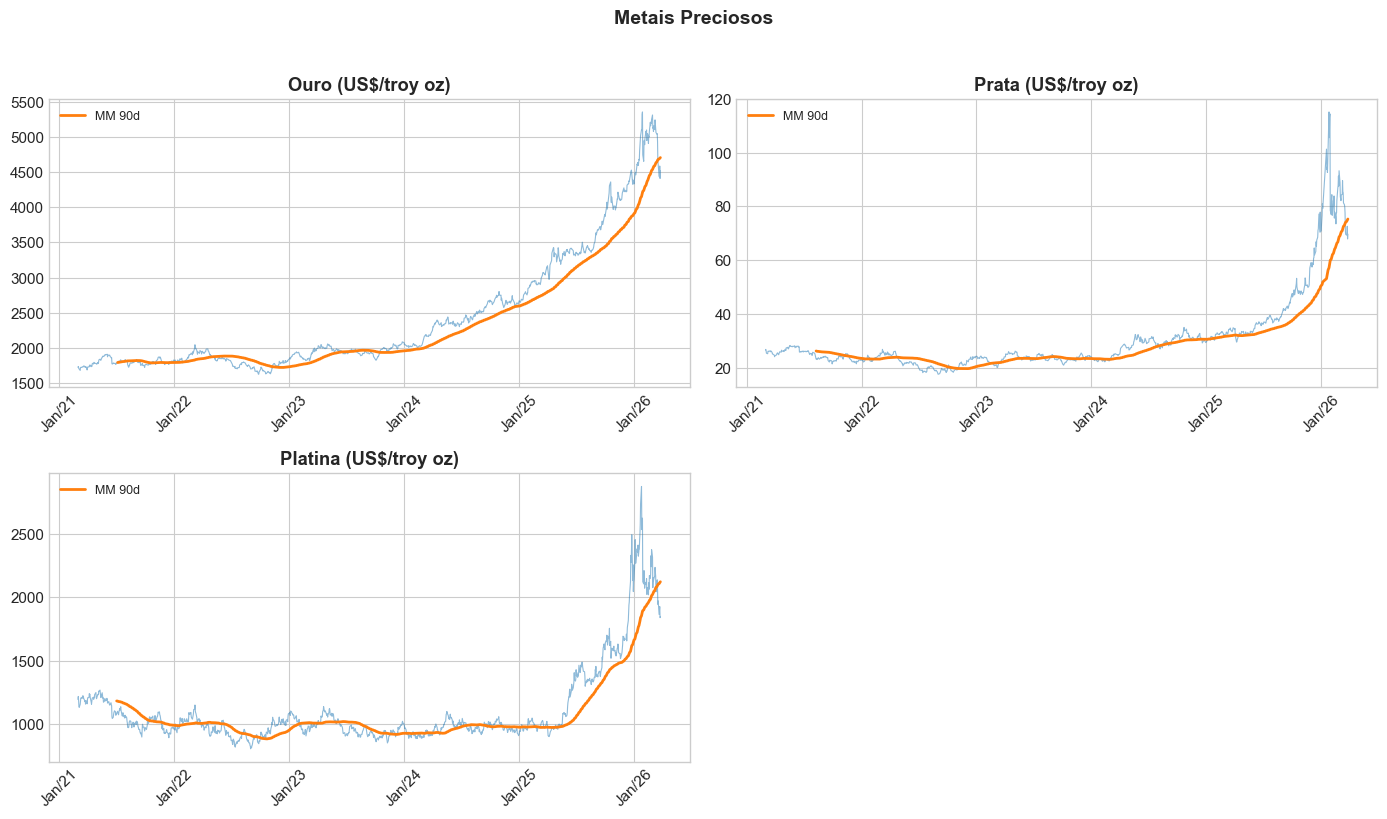

In [3]:
precious = [('gold', 'Ouro', 'US$/troy oz'), ('silver', 'Prata', 'US$/troy oz'),
            ('platinum', 'Platina', 'US$/troy oz'), ('palladium', 'Paládio', 'US$/troy oz')]
available = [(c, l, u) for c, l, u in precious if c in df.columns]

n = len(available)
fig, axes = plt.subplots(2, 2, figsize=(14, 8))
for i, (col, label, unit) in enumerate(available):
    ax = axes.flat[i]
    s = df[col].dropna()
    r90 = s.rolling(90).mean()
    ax.plot(s.index, s, alpha=0.5, linewidth=0.8, color='#1f77b4')
    ax.plot(s.index, r90, linewidth=2, color='#ff7f0e', label='MM 90d')
    ax.set_title(f'{label} ({unit})', fontweight='bold')
    ax.legend(fontsize=9)
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b/%y'))
    ax.tick_params(axis='x', rotation=45)
for j in range(n, 4):
    axes.flat[j].set_visible(False)

fig.suptitle('Metais Preciosos', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

## Metais Base
Cobre, Alumínio, Níquel, Zinco, Estanho e Chumbo.

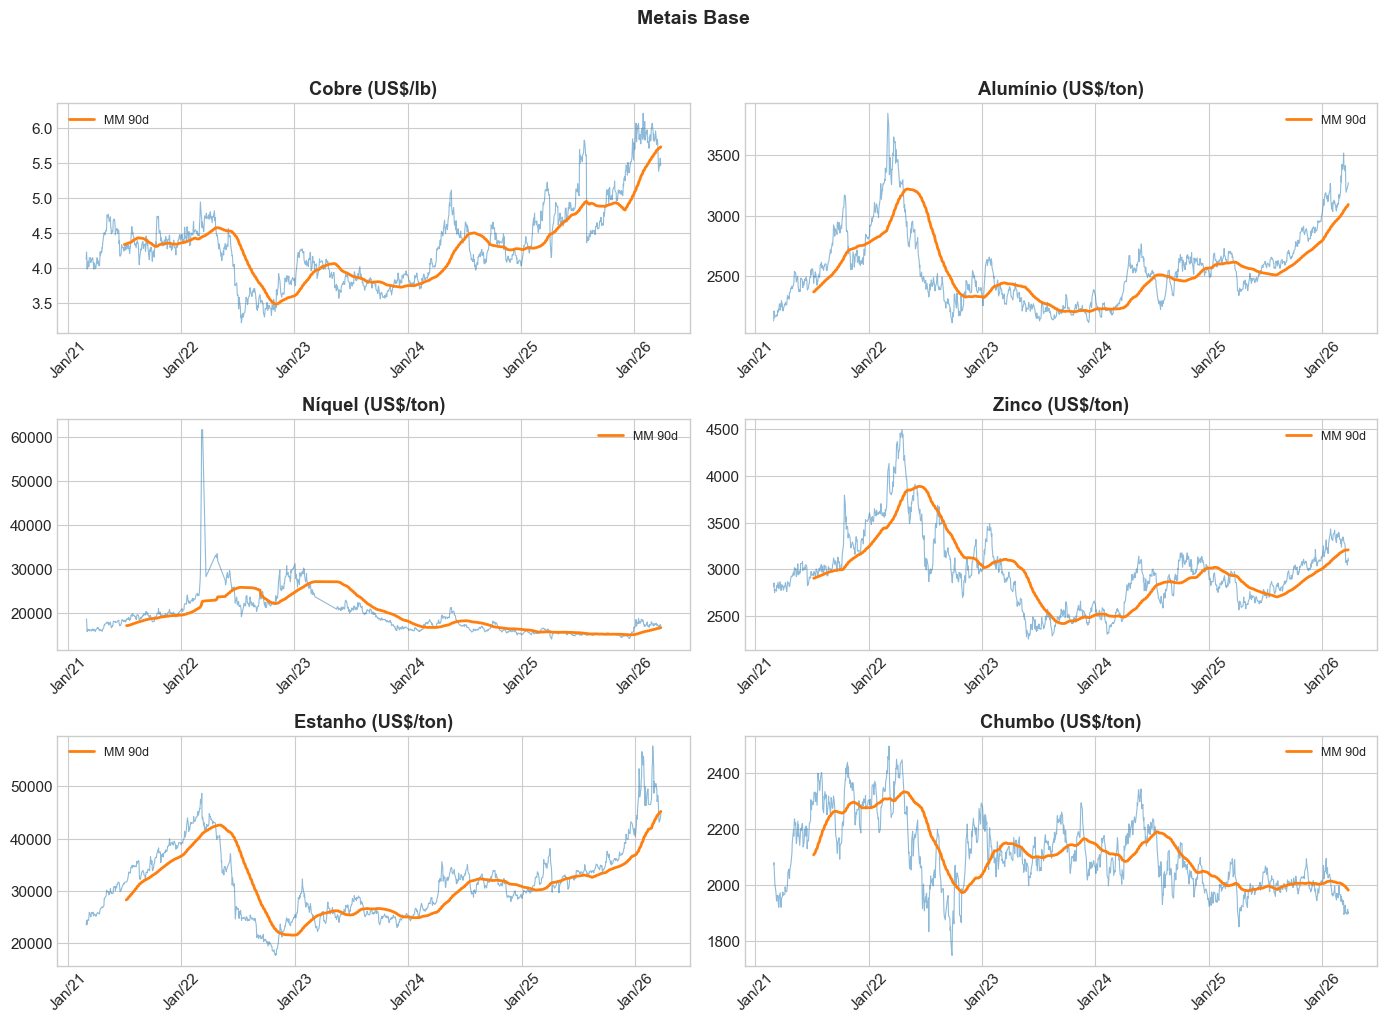

In [4]:
base_metals = [
    ('copper', 'Cobre', 'US$/lb'), ('aluminum', 'Alumínio', 'US$/ton'),
    ('nickel', 'Níquel', 'US$/ton'), ('zinc', 'Zinco', 'US$/ton'),
    ('tin', 'Estanho', 'US$/ton'), ('lead', 'Chumbo', 'US$/ton'),
]

fig, axes = plt.subplots(3, 2, figsize=(14, 10))
for ax, (col, label, unit) in zip(axes.flat, base_metals):
    if col not in df.columns:
        ax.set_visible(False)
        continue
    s = df[col].dropna()
    r90 = s.rolling(90).mean()
    ax.plot(s.index, s, alpha=0.5, linewidth=0.8, color='#1f77b4')
    ax.plot(s.index, r90, linewidth=2, color='#ff7f0e', label='MM 90d')
    ax.set_title(f'{label} ({unit})', fontweight='bold')
    ax.legend(fontsize=9)
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b/%y'))
    ax.tick_params(axis='x', rotation=45)

fig.suptitle('Metais Base', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

## Minério de Ferro 62% Fe CFR
Principal benchmark para minério de ferro no mercado internacional.

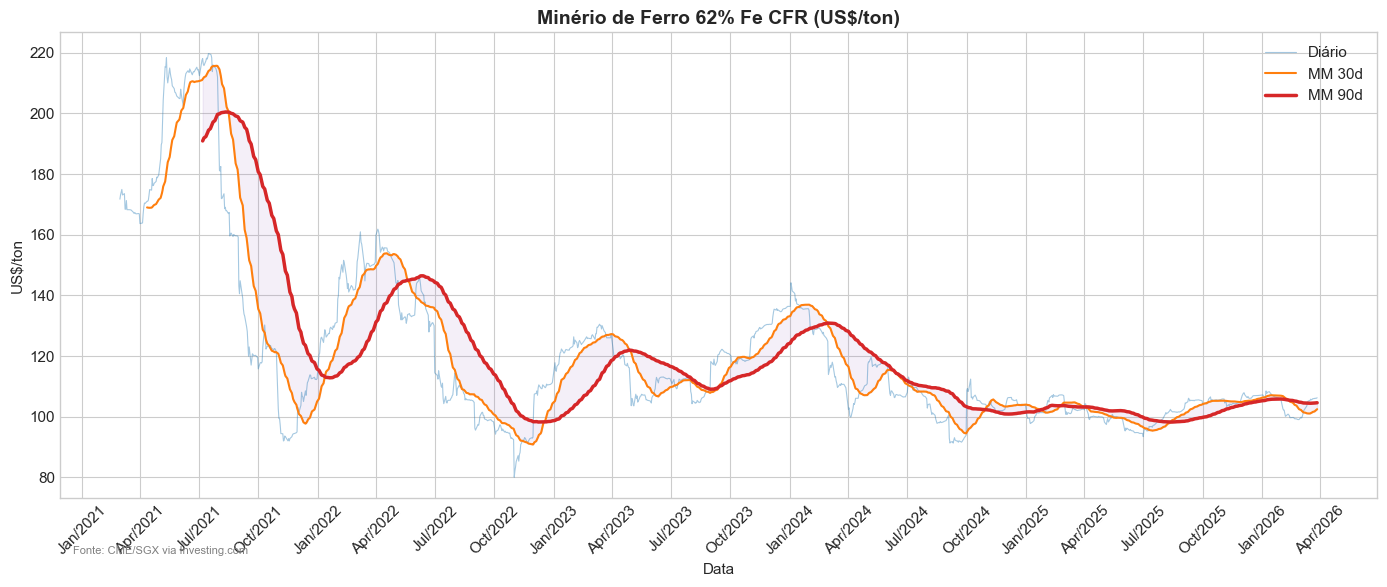

In [5]:
fig, ax = plt.subplots(figsize=(14, 6))

s = df['iron_ore_62fe'].dropna()
r30 = s.rolling(30).mean()
r90 = s.rolling(90).mean()

ax.plot(s.index, s, alpha=0.4, linewidth=0.8, color='#1f77b4', label='Diário')
ax.plot(s.index, r30, linewidth=1.5, color='#ff7f0e', label='MM 30d')
ax.plot(s.index, r90, linewidth=2.5, color='#d62728', label='MM 90d')
ax.fill_between(s.index, r30, r90, alpha=0.1, color='#9467bd')

ax.set_title('Minério de Ferro 62% Fe CFR (US$/ton)', fontsize=14, fontweight='bold')
ax.set_ylabel('US$/ton')
ax.set_xlabel('Data')
ax.legend()
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b/%Y'))
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
plt.xticks(rotation=45)
ax.annotate('Fonte: CME/SGX via Investing.com', xy=(0.01, -0.12), xycoords='axes fraction', fontsize=8, color='gray')
plt.tight_layout()
plt.show()

## Energia e Industriais
Carvão Newcastle, Aço HRC China, Urânio e comparação normalizada.

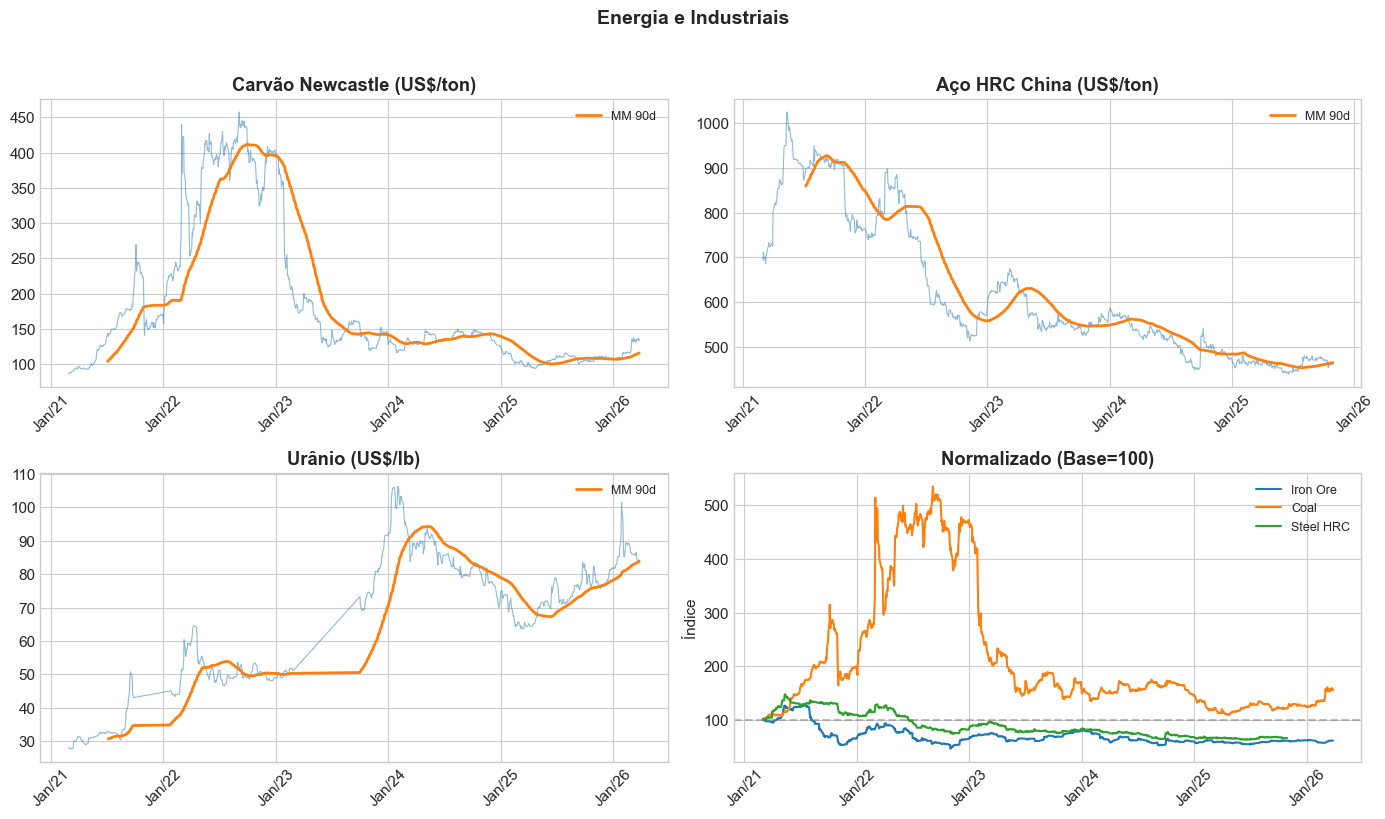

In [6]:
fig, axes = plt.subplots(2, 2, figsize=(14, 8))

energy_cols = [
    ('coal_newcastle', 'Carvão Newcastle', 'US$/ton'),
    ('steel_hrc_china', 'Aço HRC China', 'US$/ton'),
    ('uranium', 'Urânio', 'US$/lb'),
]
for ax, (col, label, unit) in zip(axes.flat[:3], energy_cols):
    if col not in df.columns:
        ax.set_visible(False)
        continue
    s = df[col].dropna()
    r90 = s.rolling(90).mean()
    ax.plot(s.index, s, alpha=0.5, linewidth=0.8, color='#1f77b4')
    ax.plot(s.index, r90, linewidth=2, color='#ff7f0e', label='MM 90d')
    ax.set_title(f'{label} ({unit})', fontweight='bold')
    ax.legend(fontsize=9)
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b/%y'))
    ax.tick_params(axis='x', rotation=45)

# Comparação normalizada
ax = axes[1, 1]
for col, label, color in [('iron_ore_62fe', 'Minério de Ferro', '#1f77b4'),
                           ('coal_newcastle', 'Carvão', '#ff7f0e'),
                           ('steel_hrc_china', 'Aço HRC', '#2ca02c')]:
    if col not in df.columns:
        continue
    s = df[col].dropna()
    if len(s) > 0:
        normalized = (s / s.iloc[0]) * 100
        ax.plot(normalized.index, normalized, label=label, color=color, linewidth=1.5)
ax.axhline(y=100, color='gray', linestyle='--', alpha=0.5)
ax.set_title('Normalizado (Base=100)', fontweight='bold')
ax.set_ylabel('Índice')
ax.legend(fontsize=9)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b/%y'))
ax.tick_params(axis='x', rotation=45)

fig.suptitle('Energia e Industriais', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

## Desempenho Relativo - Todas as Commodities (Base 100)

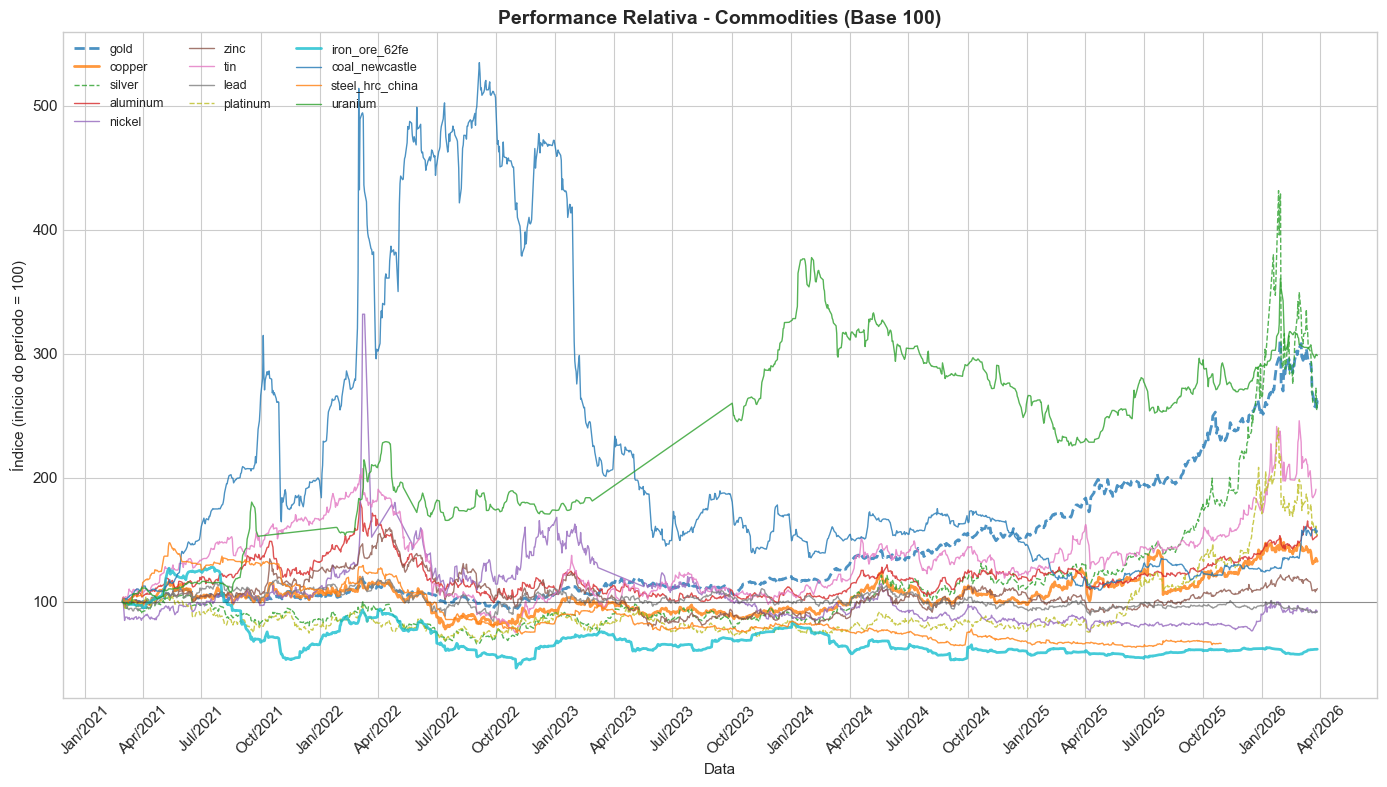

In [7]:
fig, ax = plt.subplots(figsize=(14, 8))

precious_cols = ['gold', 'silver', 'platinum']
industrial_cols = ['copper', 'aluminum', 'nickel', 'zinc', 'iron_ore_62fe', 'coal_newcastle']

for col in df.columns:
    s = df[col].dropna()
    if len(s) < 10:
        continue
    normalized = (s / s.iloc[0]) * 100
    ls = '--' if col in precious_cols else '-'
    lw = 2 if col in ['gold', 'iron_ore_62fe', 'copper'] else 1
    ax.plot(normalized.index, normalized, label=col, linestyle=ls, linewidth=lw, alpha=0.8)

ax.axhline(y=100, color='black', linestyle='-', alpha=0.3, linewidth=0.8)
ax.set_title('Desempenho Relativo - Commodities (Base 100)', fontsize=14, fontweight='bold')
ax.set_ylabel('Índice (início do período = 100)')
ax.set_xlabel('Data')
ax.legend(loc='upper left', ncol=3, fontsize=9)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b/%Y'))
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Correlação dos Retornos Diários

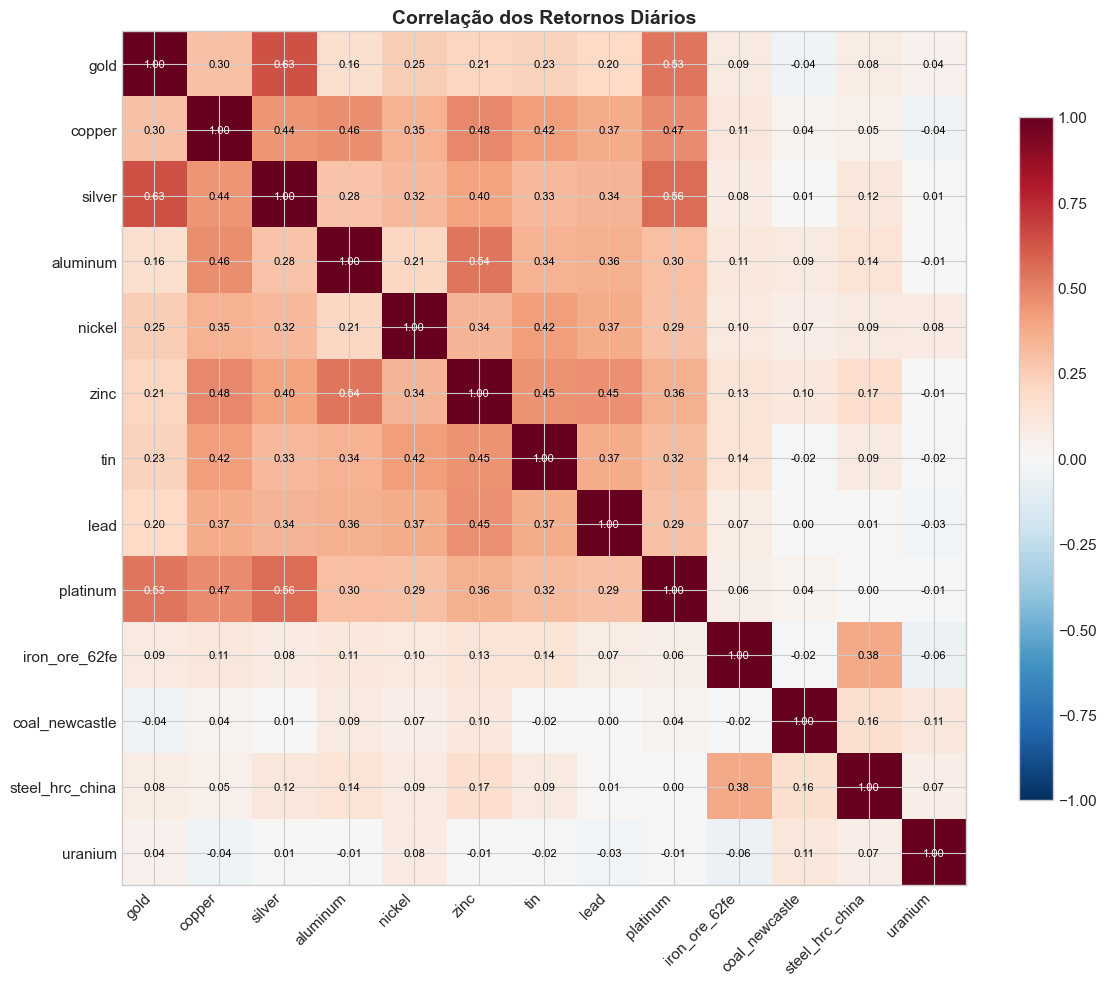

In [8]:
returns = df.pct_change().dropna()
corr = returns.corr()

fig, ax = plt.subplots(figsize=(12, 10))
im = ax.imshow(corr, cmap='RdBu_r', vmin=-1, vmax=1, aspect='auto')

ax.set_xticks(range(len(corr.columns)))
ax.set_yticks(range(len(corr.columns)))
ax.set_xticklabels(corr.columns, rotation=45, ha='right')
ax.set_yticklabels(corr.columns)

for i in range(len(corr)):
    for j in range(len(corr)):
        val = corr.iloc[i, j]
        color = 'white' if abs(val) > 0.5 else 'black'
        ax.text(j, i, f'{val:.2f}', ha='center', va='center', fontsize=8, color=color)

plt.colorbar(im, ax=ax, shrink=0.8)
ax.set_title('Correlação dos Retornos Diários', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## Volatilidade - Desvio-Padrão 30 Dias dos Retornos

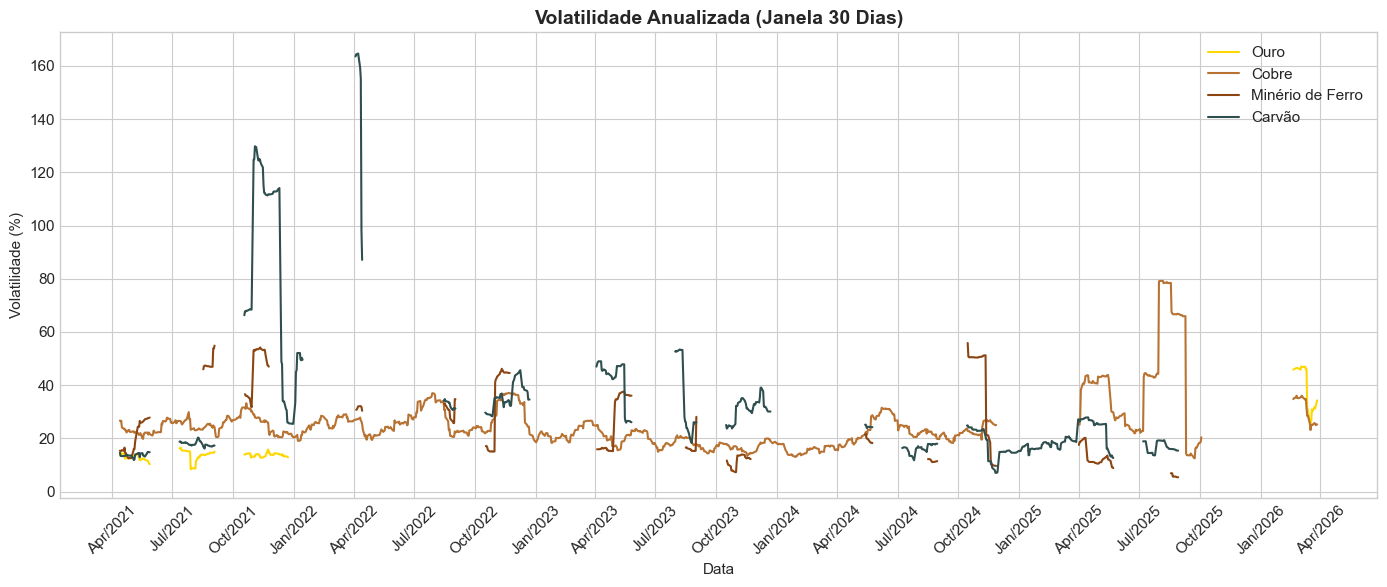

In [9]:
fig, ax = plt.subplots(figsize=(14, 6))

key_commodities = [('gold', 'Ouro', '#FFD700'), ('copper', 'Cobre', '#B87333'),
                   ('iron_ore_62fe', 'Minério de Ferro', '#8B4513'),
                   ('coal_newcastle', 'Carvão', '#2F4F4F')]

for col, label, color in key_commodities:
    if col not in df.columns:
        continue
    vol = df[col].pct_change().rolling(30).std() * np.sqrt(252) * 100
    ax.plot(vol.index, vol, label=label, color=color, linewidth=1.5)

ax.set_title('Volatilidade Anualizada (Janela 30 Dias)', fontsize=14, fontweight='bold')
ax.set_ylabel('Volatilidade (%)')
ax.set_xlabel('Data')
ax.legend()
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b/%Y'))
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Painel Resumo - Principais Commodities

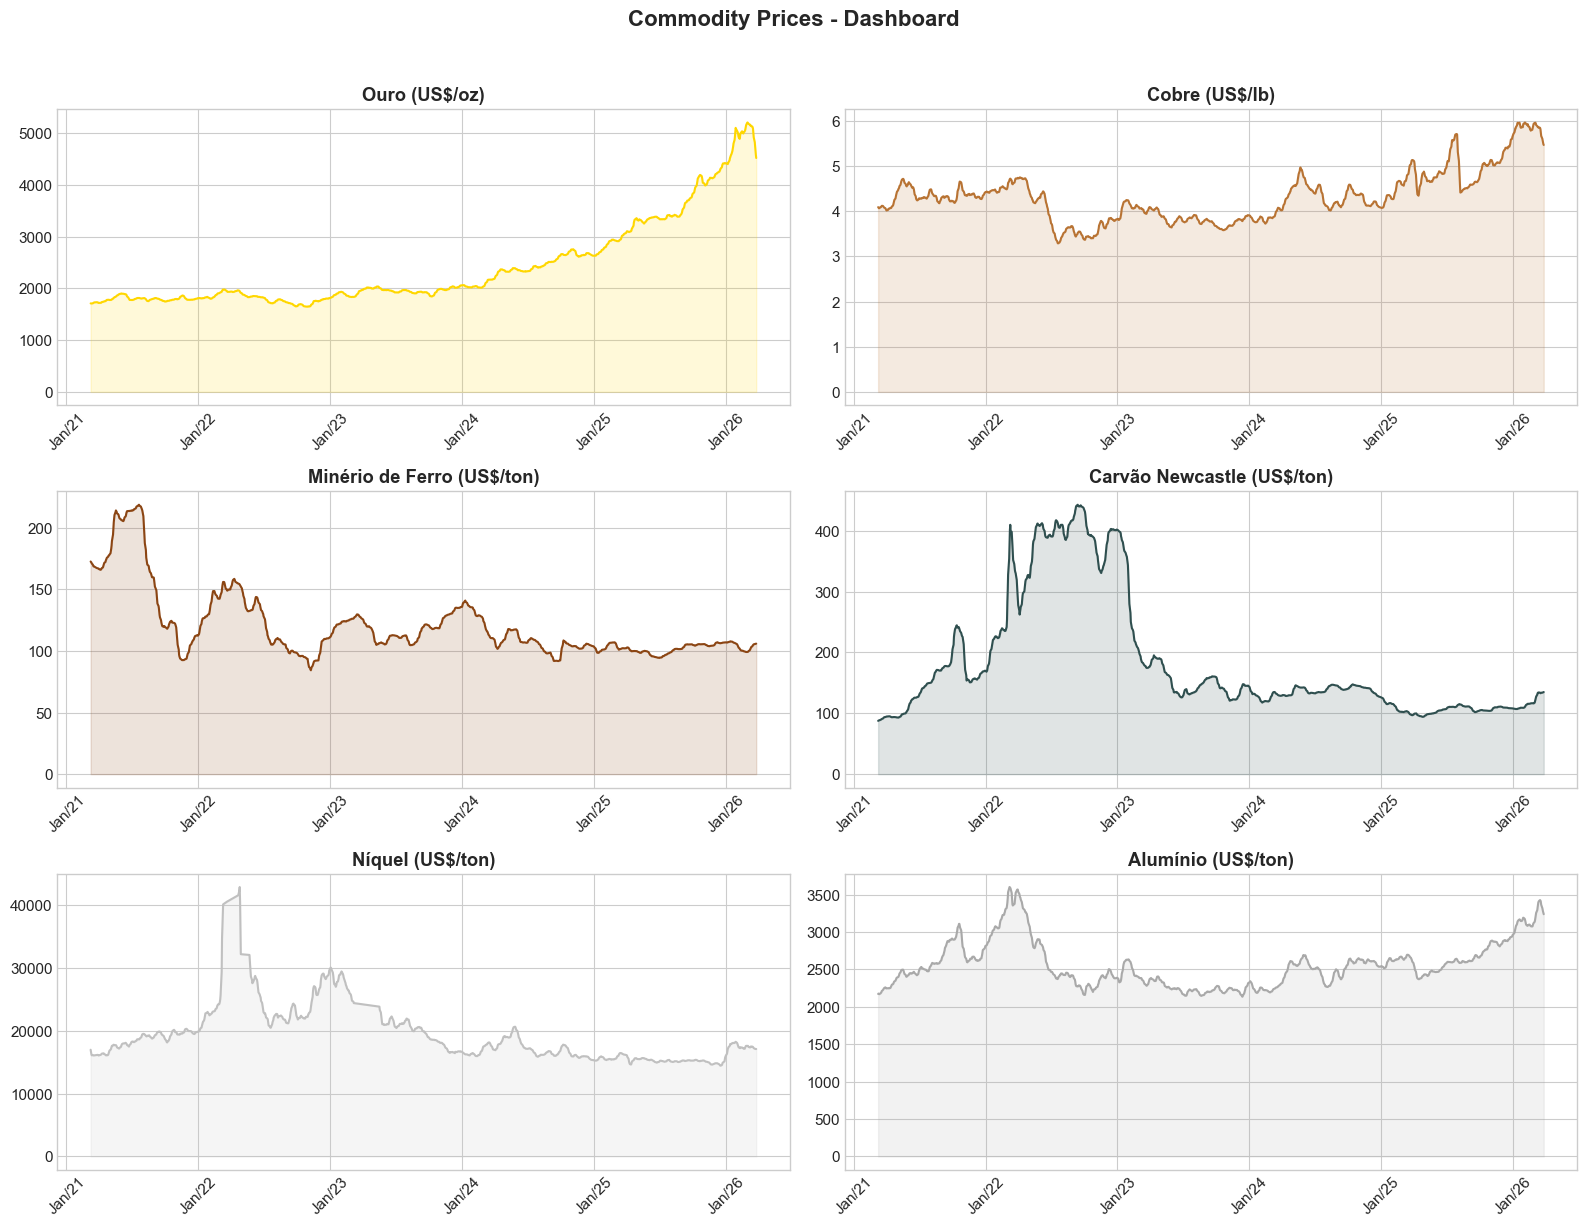

In [10]:
fig, axes = plt.subplots(3, 2, figsize=(16, 12))

dashboard = [
    ('gold', 'Ouro (US$/oz)', '#FFD700'),
    ('copper', 'Cobre (US$/lb)', '#B87333'),
    ('iron_ore_62fe', 'Minério de Ferro (US$/ton)', '#8B4513'),
    ('coal_newcastle', 'Carvão Newcastle (US$/ton)', '#2F4F4F'),
    ('nickel', 'Níquel (US$/ton)', '#C0C0C0'),
    ('aluminum', 'Alumínio (US$/ton)', '#A9A9A9'),
]

for ax, (col, title, color) in zip(axes.flat, dashboard):
    if col not in df.columns:
        ax.set_visible(False)
        continue
    s = df[col].dropna()
    r7 = s.rolling(7).mean()
    ax.plot(r7.index, r7, color=color, linewidth=1.5)
    ax.fill_between(r7.index, r7, alpha=0.15, color=color)
    ax.set_title(title, fontweight='bold')
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b/%y'))
    ax.tick_params(axis='x', rotation=45)

fig.suptitle('Preços de Commodities - Painel Resumo', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()